<a href="https://colab.research.google.com/github/ganeevsingh18/Diffusion/blob/main/Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


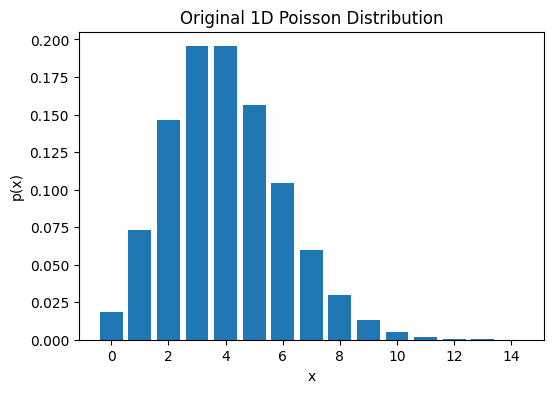

In [45]:


# ============================================================
# 1. Create a 1D non-Gaussian probability distribution
# ============================================================

def poisson_pmf(x, lam=4.0):
    """
    Poisson probability mass function.
    """
    from math import factorial
    probs = np.array([(lam ** int(k)) * np.exp(-lam) / factorial(int(k)) for k in x])
    return probs / probs.sum()


# Discrete support
x_values = np.arange(0, 15)
p_values = poisson_pmf(x_values, lam=4.0)

plt.figure(figsize=(6, 4))
plt.bar(x_values, p_values)
plt.title("Original 1D Poisson Distribution")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.show()


In [46]:


# ============================================================
# 2. Sample data from this distribution
# ============================================================

def sample_from_distribution(n_samples=10_000):
    samples = np.random.choice(x_values, size=n_samples, p=p_values)
    samples = samples.astype(np.float32)

    return torch.tensor(samples).view(-1, 1)



raw_data = sample_from_distribution(20_000)   # shape: [N, 1]

#Normalizing the data, for stable training. Will rescale later!!
data_mean = raw_data.mean()
data_std = raw_data.std()

data = (raw_data - data_mean) / data_std


In [47]:


# ============================================================
# 3. Define diffusion process with 10 steps
# ============================================================

T = 10  # number of diffusion steps


#Forward pass:
# xt = root(alpha)*P(xt-1)+ root(1-alpha)*sigma
betas = torch.linspace(0.02, 0.25, T)          # noise schedule
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def q_sample(x0, t, noise=None):
    """
    Forward diffusion:

        x_t = sqrt(alpha_bar_t) x_0 + sqrt(1 - alpha_bar_t) epsilon

    where epsilon ~ N(0, 1)
    """
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_alpha_bar = torch.sqrt(alpha_bars[t]).view(-1, 1)
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bars[t]).view(-1, 1)

    xt = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * noise
    return xt, noise



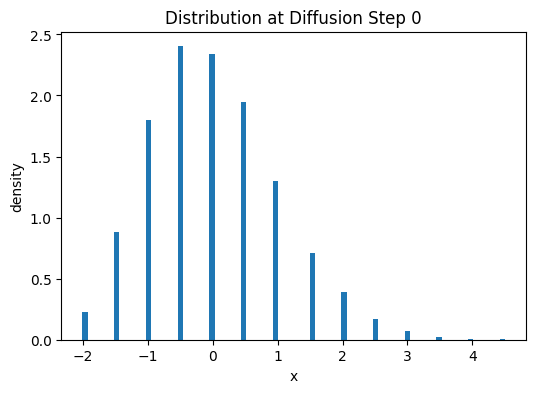

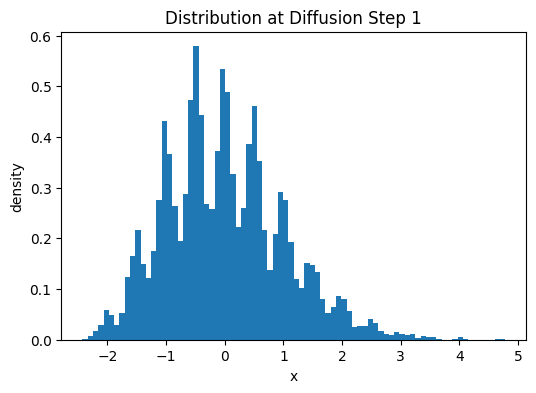

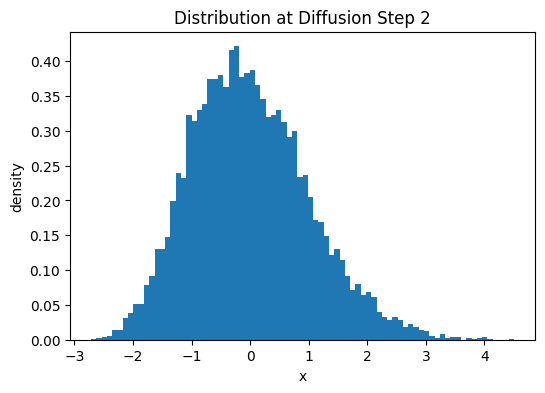

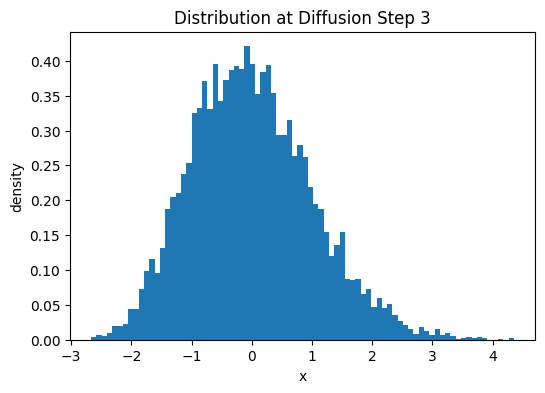

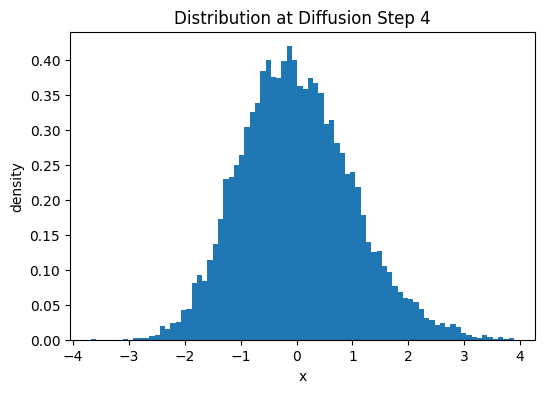

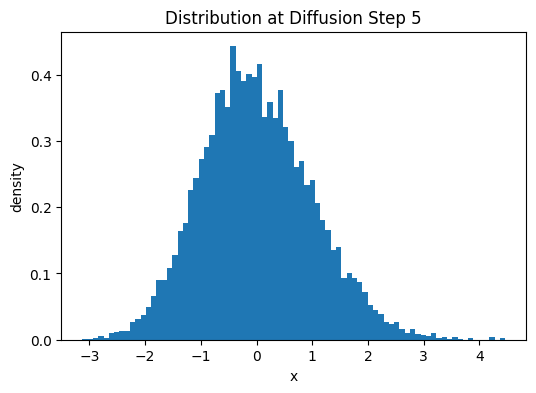

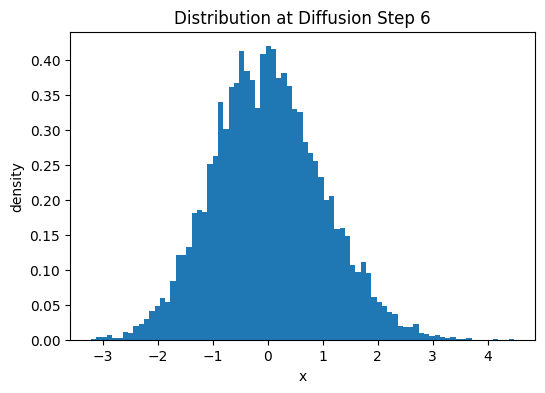

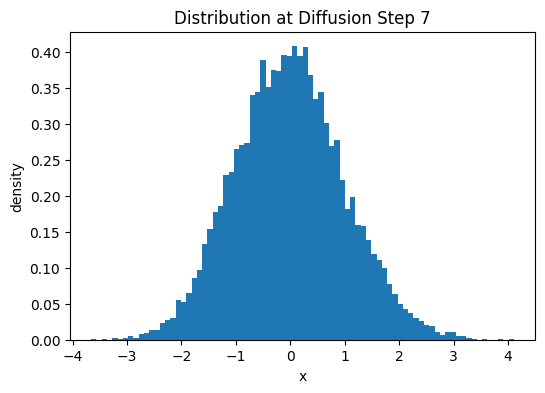

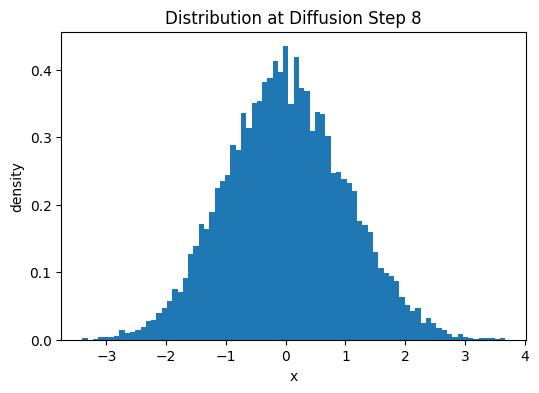

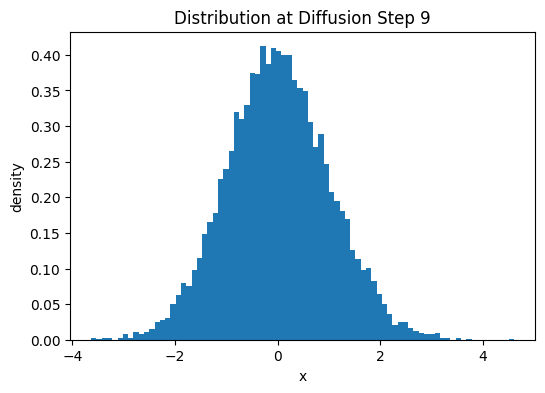

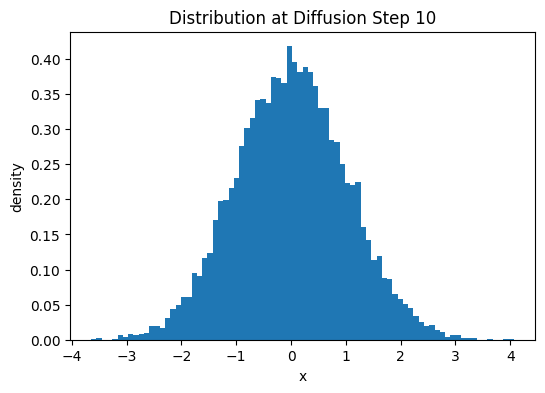

In [48]:


# ============================================================
# 4. Visualize diffusion at any step
# ============================================================

def visualize_diffusion_step(step):
    """
    step should be between 0 and T.
    step = 0 means original data.
    step = 10 means fully noised data after 10 steps.
    """
    assert 0 <= step <= T

    x0 = data[:10_000]

    if step == 0:
        xt = x0
    else:
        t = torch.full((x0.shape[0],), step - 1, dtype=torch.long)
        xt, _ = q_sample(x0, t)

    plt.figure(figsize=(6, 4))
    plt.hist(xt.detach().numpy(), bins=80, density=True)
    plt.title(f"Distribution at Diffusion Step {step}")
    plt.xlabel("x")
    plt.ylabel("density")
    plt.show()


# Try visualizing different steps
for i in range(T + 1):
    visualize_diffusion_step(i)


In [49]:

# ============================================================
# 5. Denoising neural network
# ============================================================

class Denoiser(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, xt, t):
        """
        Input:
            xt: noisy x at timestep t
            t: timestep

        Output:
            predicted noise epsilon_theta(xt, t)
        """

        # Normalize timestep to [0, 1]
        t = t.float().view(-1, 1) / T

        inp = torch.cat([xt, t], dim=1)
        return self.net(inp)


model = Denoiser()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [50]:


# ============================================================
# 6. Train with DDPM simplified ELBO loss
# ============================================================

def train(num_epochs=3000, batch_size=256):
    """
    The true DDPM objective comes from the ELBO.

    In practice, the simplified loss is:

        L = E[ || epsilon - epsilon_theta(x_t, t) ||^2 ]

    where:
        epsilon is the real Gaussian noise added
        epsilon_theta is the model's predicted noise
    """

    n = data.shape[0]

    for epoch in range(num_epochs):
        idx = torch.randint(0, n, (batch_size,))
        x0 = data[idx]

        t = torch.randint(0, T, (batch_size,), dtype=torch.long)

        xt, noise = q_sample(x0, t)

        predicted_noise = model(xt, t)

        loss = ((noise - predicted_noise) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 300 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")


train()


Epoch    0 | Loss: 0.983531
Epoch  300 | Loss: 0.656286
Epoch  600 | Loss: 0.597693
Epoch  900 | Loss: 0.519463
Epoch 1200 | Loss: 0.716299
Epoch 1500 | Loss: 0.607398
Epoch 1800 | Loss: 0.669153
Epoch 2100 | Loss: 0.559533
Epoch 2400 | Loss: 0.564627
Epoch 2700 | Loss: 0.653525


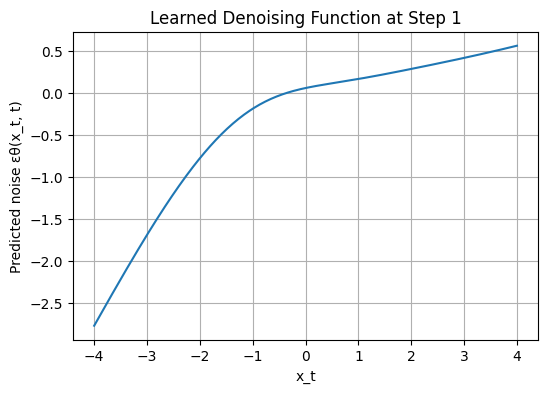

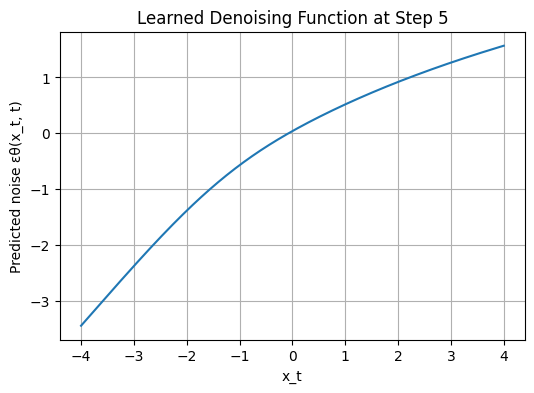

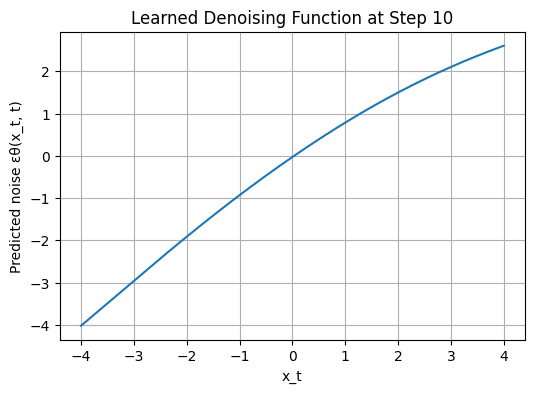

In [51]:


# ============================================================
# 7. Visualize learned denoising function at any step
# ============================================================

def visualize_denoising_function(step):
    """
    Visualizes epsilon_theta(x_t, t), the learned denoising function.

    For a fixed timestep t, it shows:
        x_t  ->  predicted noise
    """

    assert 1 <= step <= T

    t_value = step - 1

    x_grid = torch.linspace(-4, 4, 300).view(-1, 1)
    t_grid = torch.full((x_grid.shape[0],), t_value, dtype=torch.long)

    with torch.no_grad():
        predicted_noise = model(x_grid, t_grid)

    plt.figure(figsize=(6, 4))
    plt.plot(x_grid.numpy(), predicted_noise.numpy())
    plt.title(f"Learned Denoising Function at Step {step}")
    plt.xlabel("x_t")
    plt.ylabel("Predicted noise εθ(x_t, t)")
    plt.grid(True)
    plt.show()


visualize_denoising_function(1)
visualize_denoising_function(5)
visualize_denoising_function(10)



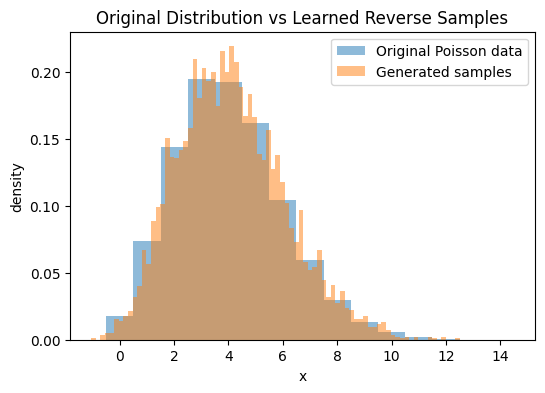

In [52]:

# ============================================================
# 8. Reverse diffusion sampling
# ============================================================

@torch.no_grad()
def sample_reverse(n_samples=5000):
    """
    Start from Gaussian noise and reverse the diffusion process.

    This generates samples from the learned model.
    """

    x = torch.randn(n_samples, 1)

    for t in reversed(range(T)):
        t_batch = torch.full((n_samples,), t, dtype=torch.long)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        predicted_noise = model(x, t_batch)

        # DDPM reverse mean:
        mean = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean

    return x


generated_norm = sample_reverse()
generated_original_scale = generated_norm * data_std + data_mean


plt.figure(figsize=(6, 4))
plt.hist(raw_data.numpy(), bins=np.arange(-0.5, 15.5, 1), density=True, alpha=0.5, label="Original Poisson data")
plt.hist(generated_original_scale.numpy(), bins=80, density=True, alpha=0.5, label="Generated samples")
plt.title("Original Distribution vs Learned Reverse Samples")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()